# Clustering Techniques Analysis: Assignment 3

---

## PROGRAMMING ASSIGNMENT

### Task
You are provided with 15 different datasets. Your task is to determine which clustering techniques apply to each dataset and which do not.

### Datasets
- circles
- moons
- anisotropic
- varied_density
- blobs
- random
- spirals
- jain
- flame
- compound
- diamonds
- cross
- concentric_rings
- noisy_moons
- blobs_with_noise

### Clustering Techniques to Test
1. K-Means++
2. K-Medoids
3. Agglomerative (Single Linkage)
4. Agglomerative (Complete Linkage)
5. Agglomerative (Average Linkage)
6. Agglomerative (Ward Linkage)
7. DBSCAN

### Requirements
- Use coding with sklearn libraries or necessary libraries
- Determine which techniques work and which fail on each dataset
- Display the techniques that work and the ones that fail for each dataset

### Deliverables
**Save the notebook as: <your_name_Assignemnt3.ipynb**
- Code implementation
- Visual displays showing results

---

In [2]:
# uncomment for scikit-learn-extra
# %pip install -q scikit-learn-extra

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering, KMeans, DBSCAN
from sklearn_extra.cluster import KMedoids
from sklearn.datasets import make_moons, make_circles, make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')


class DatasetGenerator:
    """
    Generates various synthetic datasets for clustering experiments.
    
    Parameters:
    -----------
    dataset_type : str
        Type of dataset to generate. Options:
        Basic shapes:
        - 'circles': Concentric circles
        - 'moons': Half moons
        - 'blobs': Standard Gaussian blobs
        - 'anisotropic': Elongated blobs
        - 'varied_density': Blobs with different densities
        - 'uneven_sizes': Clusters with different sizes
        - 'random': Random uniform distribution
        
        Complex patterns:
        - 'spirals': Intertwined spirals
        - 'jain': Two crescents with different densities
        - 'flame': Varying density clusters
        - 'compound': Six Gaussian clusters
        - 'diamonds': Diamond-shaped clusters
        - 'cross': X-shaped pattern
        - 'concentric_rings': Multiple concentric circles (3 rings)
        - 'grid': Grid pattern (9 clusters)
        - 'noisy_moons': Half moons with high noise
        - 'blobs_with_noise': Clusters with background noise
        
    n_samples : int, default=300
        Number of samples to generate
    noise : float, default=0.05
        Amount of noise to add
    random_state : int, default=42
        Random seed for reproducibility
    """
    
    def __init__(self, dataset_type, n_samples=300, noise=0.05, random_state=42):
        self.dataset_type = dataset_type.lower()
        self.n_samples = n_samples
        self.noise = noise
        self.random_state = random_state
        np.random.seed(random_state)
        
        # Validate dataset type
        valid_types = [
            # Basic
            'circles', 'moons', 'anisotropic', 'varied_density', 
            'uneven_sizes', 'random', 'blobs',
            # Complex
            'spirals', 'jain', 'flame', 'compound', 'diamonds',
            'cross', 'concentric_rings', 'grid', 'noisy_moons', 'blobs_with_noise'
        ]
        if self.dataset_type not in valid_types:
            raise ValueError(f"Invalid dataset_type. Choose from: {valid_types}")
        
        self.X = None
        self.y_true = None
        self.X_scaled = None
        self.n_clusters = None
        
    def generate(self):
        """Generate the dataset based on the specified type."""
        
        # Basic datasets
        if self.dataset_type == 'circles':
            self.X, self.y_true = make_circles(
                n_samples=self.n_samples, 
                factor=0.5, 
                noise=self.noise,
                random_state=self.random_state
            )
            self.n_clusters = 2
            
        elif self.dataset_type == 'moons':
            self.X, self.y_true = make_moons(
                n_samples=self.n_samples, 
                noise=self.noise,
                random_state=self.random_state
            )
            self.n_clusters = 2
            
        elif self.dataset_type == 'anisotropic':
            X, y = make_blobs(
                n_samples=self.n_samples, 
                centers=3, 
                random_state=self.random_state
            )
            transformation = [[0.6, -0.6], [-0.4, 0.8]]
            self.X = np.dot(X, transformation)
            self.y_true = y
            self.n_clusters = 3
            
        elif self.dataset_type == 'varied_density':
            self.X, self.y_true = make_blobs(
                n_samples=self.n_samples,
                centers=[[0, 0], [3, 3]],
                cluster_std=[0.5, 1.5],
                random_state=self.random_state
            )
            self.n_clusters = 2
            
        elif self.dataset_type == 'uneven_sizes':
            self.X, self.y_true = make_blobs(
                n_samples=[100, 200],
                centers=[[0, 0], [4, 4]],
                cluster_std=[0.5, 1.0],
                random_state=self.random_state
            )
            self.n_clusters = 2
            
        elif self.dataset_type == 'random':
            self.X = np.random.rand(self.n_samples, 2) * 4 - 2
            self.y_true = np.zeros(self.n_samples, dtype=int)
            self.n_clusters = 2
            
        elif self.dataset_type == 'blobs':
            self.X, self.y_true = make_blobs(
                n_samples=self.n_samples,
                centers=3,
                cluster_std=0.6,
                random_state=self.random_state
            )
            self.n_clusters = 3
        
        # Complex datasets
        elif self.dataset_type == 'spirals':
            self._generate_spirals()
            
        elif self.dataset_type == 'jain':
            self._generate_jain()
            
        elif self.dataset_type == 'flame':
            self._generate_flame()
            
        elif self.dataset_type == 'compound':
            self._generate_compound()
            
        elif self.dataset_type == 'diamonds':
            self._generate_diamonds()
            
        elif self.dataset_type == 'cross':
            self._generate_cross()
            
        elif self.dataset_type == 'concentric_rings':
            self._generate_concentric_rings()
            
        elif self.dataset_type == 'grid':
            self._generate_grid()
            
        elif self.dataset_type == 'noisy_moons':
            self._generate_noisy_moons()
            
        elif self.dataset_type == 'blobs_with_noise':
            self._generate_blobs_with_noise()
        
        # Standardize features
        self.X_scaled = StandardScaler().fit_transform(self.X)
        
        return self
    
    def _generate_spirals(self):
        """Generate two intertwined spirals."""
        n_points = self.n_samples // 2
        theta = np.linspace(0, 4 * np.pi, n_points)
        
        # Spiral 1
        r1 = theta
        x1 = r1 * np.cos(theta) + np.random.randn(n_points) * self.noise * 5
        y1 = r1 * np.sin(theta) + np.random.randn(n_points) * self.noise * 5
        
        # Spiral 2 (rotated by pi)
        r2 = theta
        x2 = r2 * np.cos(theta + np.pi) + np.random.randn(n_points) * self.noise * 5
        y2 = r2 * np.sin(theta + np.pi) + np.random.randn(n_points) * self.noise * 5
        
        self.X = np.vstack([np.column_stack([x1, y1]), np.column_stack([x2, y2])])
        self.y_true = np.hstack([np.zeros(n_points), np.ones(n_points)])
        self.n_clusters = 2
    
    def _generate_jain(self):
        """Generate Jain dataset: two crescents with different densities."""
        # Dense crescent
        n_dense = int(self.n_samples * 0.7)
        theta1 = np.linspace(0, np.pi, n_dense)
        r1 = 1
        x1 = r1 * np.cos(theta1) + np.random.randn(n_dense) * self.noise
        y1 = r1 * np.sin(theta1) + np.random.randn(n_dense) * self.noise
        
        # Sparse crescent
        n_sparse = self.n_samples - n_dense
        theta2 = np.linspace(0, np.pi, n_sparse)
        r2 = 2
        x2 = r2 * np.cos(theta2) + 1 + np.random.randn(n_sparse) * self.noise
        y2 = r2 * np.sin(theta2) - 1 + np.random.randn(n_sparse) * self.noise
        
        self.X = np.vstack([np.column_stack([x1, y1]), np.column_stack([x2, y2])])
        self.y_true = np.hstack([np.zeros(n_dense), np.ones(n_sparse)])
        self.n_clusters = 2
    
    def _generate_flame(self):
        """Generate flame-shaped dataset with varying density."""
        n_per_cluster = self.n_samples // 2
        
        # Dense flame base
        x1 = np.random.randn(n_per_cluster) * 0.3
        y1 = np.random.randn(n_per_cluster) * 0.3
        
        # Sparse flame tip
        x2 = np.random.randn(n_per_cluster) * 0.8 + 2
        y2 = np.random.randn(n_per_cluster) * 1.5 + 1
        
        self.X = np.vstack([np.column_stack([x1, y1]), np.column_stack([x2, y2])])
        self.y_true = np.hstack([np.zeros(n_per_cluster), np.ones(n_per_cluster)])
        self.n_clusters = 2
    
    def _generate_compound(self):
        """Generate six Gaussian clusters (compound dataset)."""
        centers = [[0, 0], [0, 3], [3, 0], [3, 3], [1.5, 1.5], [4.5, 1.5]]
        self.X, self.y_true = make_blobs(
            n_samples=self.n_samples,
            centers=centers,
            cluster_std=0.3,
            random_state=self.random_state
        )
        self.n_clusters = 6
    
    def _generate_diamonds(self):
        """Generate two diamond-shaped clusters."""
        n_per_cluster = self.n_samples // 2
        
        # Diamond 1
        t1 = np.linspace(0, 2*np.pi, n_per_cluster)
        r1 = 1 + 0.5 * np.abs(np.sin(4*t1))
        x1 = r1 * np.cos(t1) + np.random.randn(n_per_cluster) * self.noise
        y1 = r1 * np.sin(t1) + np.random.randn(n_per_cluster) * self.noise
        
        # Diamond 2 (shifted)
        t2 = np.linspace(0, 2*np.pi, n_per_cluster)
        r2 = 1 + 0.5 * np.abs(np.sin(4*t2))
        x2 = r2 * np.cos(t2) + 4 + np.random.randn(n_per_cluster) * self.noise
        y2 = r2 * np.sin(t2) + np.random.randn(n_per_cluster) * self.noise
        
        self.X = np.vstack([np.column_stack([x1, y1]), np.column_stack([x2, y2])])
        self.y_true = np.hstack([np.zeros(n_per_cluster), np.ones(n_per_cluster)])
        self.n_clusters = 2
    
    def _generate_cross(self):
        """Generate X-shaped (cross) pattern."""
        n_per_line = self.n_samples // 2
        
        # Line 1: y = x
        x1 = np.linspace(-2, 2, n_per_line)
        y1 = x1 + np.random.randn(n_per_line) * self.noise * 2
        
        # Line 2: y = -x
        x2 = np.linspace(-2, 2, n_per_line)
        y2 = -x2 + np.random.randn(n_per_line) * self.noise * 2
        
        self.X = np.vstack([np.column_stack([x1, y1]), np.column_stack([x2, y2])])
        self.y_true = np.hstack([np.zeros(n_per_line), np.ones(n_per_line)])
        self.n_clusters = 2
    
    def _generate_concentric_rings(self):
        """Generate multiple concentric rings."""
        n_per_ring = self.n_samples // 3
        
        rings = []
        labels = []
        for i, radius in enumerate([1, 2, 3]):
            theta = np.linspace(0, 2*np.pi, n_per_ring)
            x = radius * np.cos(theta) + np.random.randn(n_per_ring) * self.noise
            y = radius * np.sin(theta) + np.random.randn(n_per_ring) * self.noise
            rings.append(np.column_stack([x, y]))
            labels.append(np.ones(n_per_ring) * i)
        
        self.X = np.vstack(rings)
        self.y_true = np.hstack(labels)
        self.n_clusters = 3
    
    def _generate_grid(self):
        """Generate grid pattern."""
        grid_size = 3  # 3x3 grid
        n_per_cell = self.n_samples // (grid_size ** 2)
        
        points = []
        labels = []
        label_id = 0
        
        for i in range(grid_size):
            for j in range(grid_size):
                x = np.random.randn(n_per_cell) * 0.2 + i * 2
                y = np.random.randn(n_per_cell) * 0.2 + j * 2
                points.append(np.column_stack([x, y]))
                labels.append(np.ones(n_per_cell) * label_id)
                label_id += 1
        
        self.X = np.vstack(points)
        self.y_true = np.hstack(labels)
        self.n_clusters = grid_size ** 2
    
    def _generate_noisy_moons(self):
        """Generate half moons with high noise."""
        self.X, self.y_true = make_moons(
            n_samples=self.n_samples,
            noise=0.15,  # High noise
            random_state=self.random_state
        )
        self.n_clusters = 2
    
    def _generate_blobs_with_noise(self):
        """Generate blobs with uniform background noise."""
        n_signal = int(self.n_samples * 0.7)
        n_noise = self.n_samples - n_signal
        
        # Clean blobs
        X_signal, y_signal = make_blobs(
            n_samples=n_signal,
            centers=3,
            cluster_std=0.5,
            random_state=self.random_state
        )
        
        # Uniform noise
        X_noise = np.random.rand(n_noise, 2) * 10 - 5
        y_noise = np.ones(n_noise) * -1  # Label as noise
        
        self.X = np.vstack([X_signal, X_noise])
        self.y_true = np.hstack([y_signal, y_noise])
        self.n_clusters = 3
    
    def get_data(self, scaled=True):
        """
        Get the generated data.
        
        Parameters:
        -----------
        scaled : bool, default=True
            If True, return standardized data. Otherwise, return raw data.
        
        Returns:
        --------
        X : ndarray
            Feature matrix
        y_true : ndarray
            True labels (for reference)
        n_clusters : int
            Number of clusters
        """
        if self.X is None:
            raise ValueError("Data not generated yet. Call generate() first.")
        
        if scaled:
            return self.X_scaled, self.y_true, self.n_clusters
        else:
            return self.X, self.y_true, self.n_clusters
    
    def get_info(self):
        """Get information about the dataset."""
        if self.X is None:
            return "Dataset not generated yet."
        
        return {
            'type': self.dataset_type,
            'n_samples': len(self.X),
            'n_features': self.X.shape[1],
            'n_clusters': self.n_clusters,
            'scaled': self.X_scaled is not None
        }

In [4]:
# From Clustering2.ipynb
# ==================== VISUALIZATION ====================

def plot_clusters(X, labels, title):
    """Plot clustering results"""
    plt.figure(figsize=(10, 7))
    
    unique_labels = set(labels)
    colors = plt.cm.Set1(np.linspace(0, 1, len(unique_labels)))
    
    for i, label in enumerate(sorted(unique_labels)):
        if label == -1:
            # Noise points (DBSCAN only)
            mask = labels == label
            plt.scatter(X[mask, 0], X[mask, 1], 
                       c='black', alpha=0.3, s=30, marker='x', label='Noise')
        else:
            mask = labels == label
            plt.scatter(X[mask, 0], X[mask, 1], 
                       c=[colors[i]], alpha=0.6, s=50,
                       label=f'Cluster {label}', edgecolors='black', linewidth=0.5)
    
    plt.xlabel('Age', fontsize=12, fontweight='bold')
    plt.ylabel('Spending Score', fontsize=12, fontweight='bold')
    plt.title(title, fontsize=14, fontweight='bold')
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# ==================== AGGLOMERATIVE CLUSTERING ====================

def apply_agglomerative(X, n_clusters=4, linkage_type='ward'):
    """Apply Agglomerative Clustering"""
    print(f"\nAgglomerative Clustering (linkage={linkage_type}):")
    
    model = AgglomerativeClustering(n_clusters=n_clusters, linkage=linkage_type)
    labels = model.fit_predict(X)
    
    # Print cluster sizes
    for i in range(n_clusters):
        count = np.sum(labels == i)
        print(f"  Cluster {i}: {count} points")
    
    return labels


# ==================== DBSCAN ====================

def apply_dbscan(X, eps=5, min_samples=5):

    """Apply DBSCAN Clustering"""
    print(f"\nDBSCAN (eps={eps}, min_samples={min_samples}):")
    
    model = DBSCAN(eps=eps, min_samples=min_samples)
    labels = model.fit_predict(X)
    
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    
    print(f"  Number of clusters: {n_clusters}")
    print(f"  Noise points: {n_noise}")
    
    for label in sorted(set(labels)):
        if label != -1:
            count = np.sum(labels == label)
            print(f"  Cluster {label}: {count} points")
    
    return labels

# ==================== K-Means ====================
def apply_kmeans(X, n_clusters=3):
    """Apply K-Means Clustering"""
    print(f"\nK-Means Clustering (n_clusters={n_clusters}):")
    
    model = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    labels = model.fit_predict(X)
    
    # Print cluster sizes
    for i in range(n_clusters):
        count = np.sum(labels == i)
        print(f"  Cluster {i}: {count} points")
    
    return labels

# ==================== K-Medoids ====================
def apply_kmedoids(X, n_clusters=3):
    """Apply K-Medoids Clustering"""
    print(f"\nK-Medoids Clustering (n_clusters={n_clusters}):")
    
    model = KMedoids(n_clusters=n_clusters, random_state=42, method='pam')
    labels = model.fit_predict(X)
    
    # Print cluster sizes
    for i in range(n_clusters):
        count = np.sum(labels == i)
        print(f"  Cluster {i}: {count} points")
    
    return labels


CLUSTERING COMPARISON: Hierarchical vs Partitional Methods
Testing 15 different dataset types

📊 Showing all original datasets...


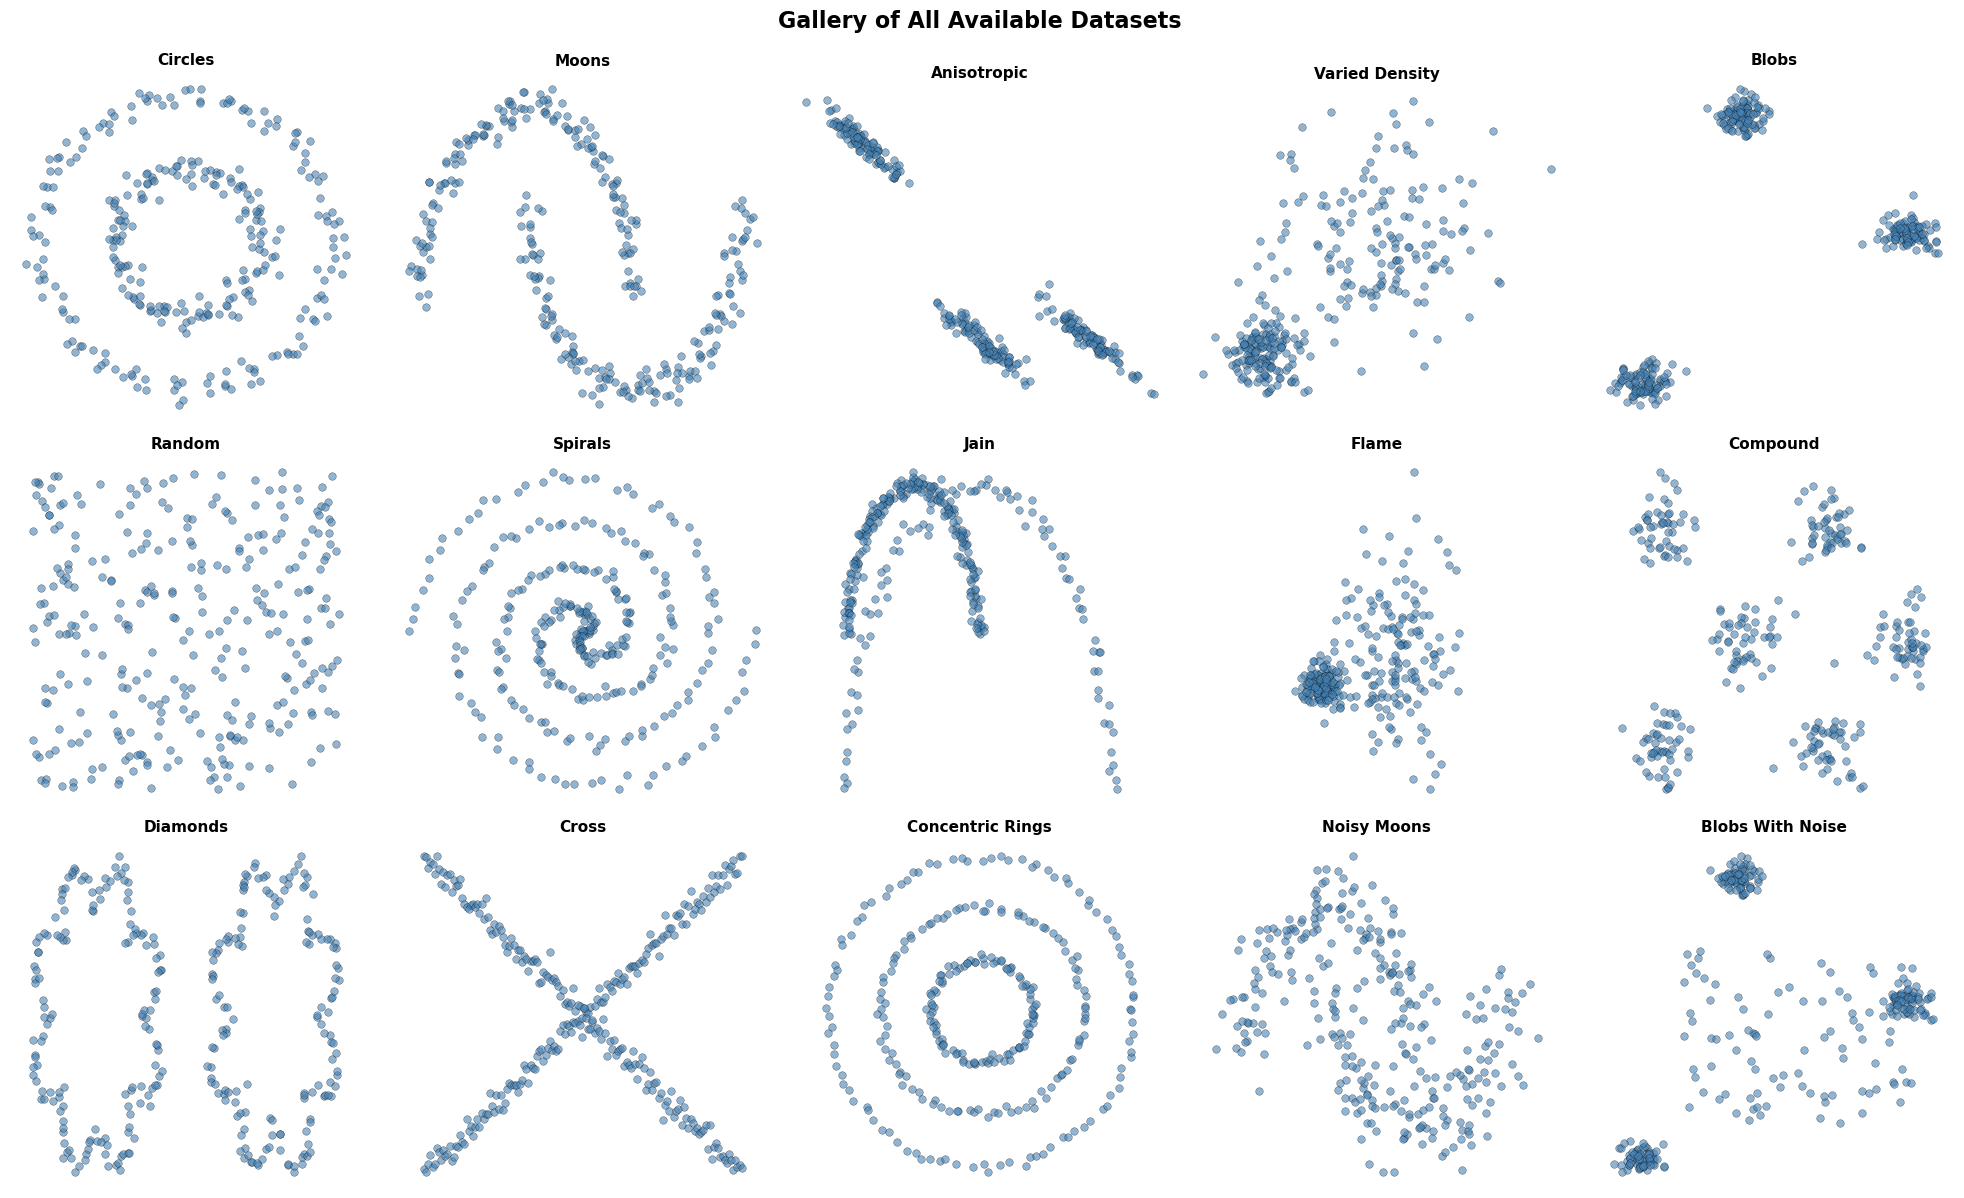


DBSCAN (eps=0.2, min_samples=3):
  Number of clusters: 23
  Noise points: 56
  Cluster 0: 145 points
  Cluster 1: 5 points
  Cluster 2: 4 points
  Cluster 3: 5 points
  Cluster 4: 8 points
  Cluster 5: 8 points
  Cluster 6: 4 points
  Cluster 7: 3 points
  Cluster 8: 3 points
  Cluster 9: 3 points
  Cluster 10: 3 points
  Cluster 11: 4 points
  Cluster 12: 3 points
  Cluster 13: 4 points
  Cluster 14: 8 points
  Cluster 15: 4 points
  Cluster 16: 5 points
  Cluster 17: 9 points
  Cluster 18: 3 points
  Cluster 19: 3 points
  Cluster 20: 3 points
  Cluster 21: 4 points
  Cluster 22: 3 points


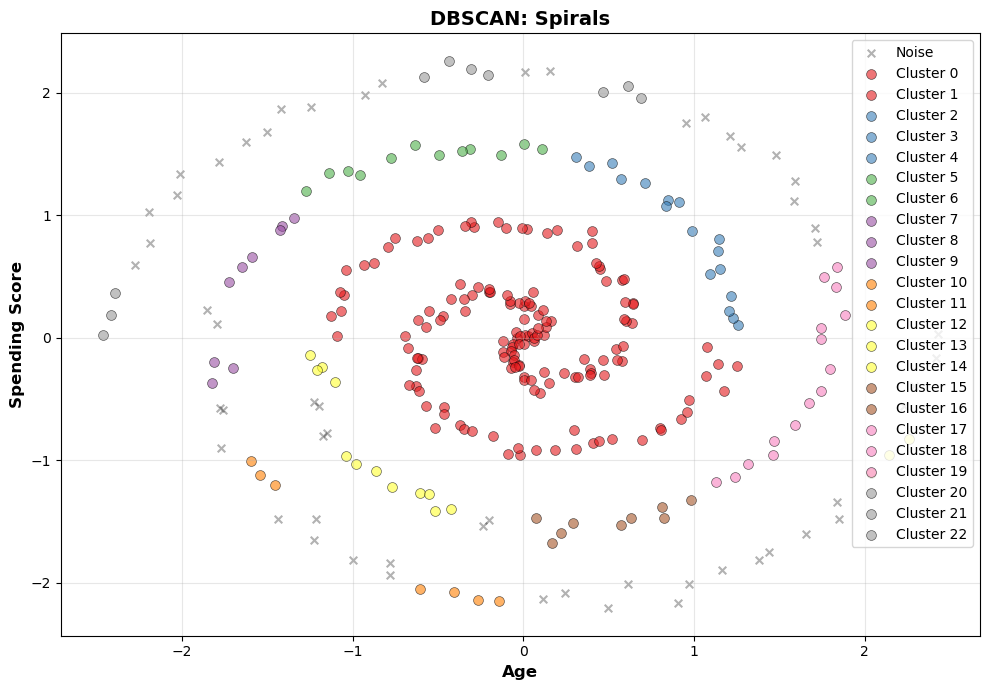


DBSCAN (eps=0.2, min_samples=3):
  Number of clusters: 13
  Noise points: 7
  Cluster 0: 245 points
  Cluster 1: 5 points
  Cluster 2: 3 points
  Cluster 3: 3 points
  Cluster 4: 4 points
  Cluster 5: 5 points
  Cluster 6: 6 points
  Cluster 7: 3 points
  Cluster 8: 6 points
  Cluster 9: 3 points
  Cluster 10: 3 points
  Cluster 11: 4 points
  Cluster 12: 3 points


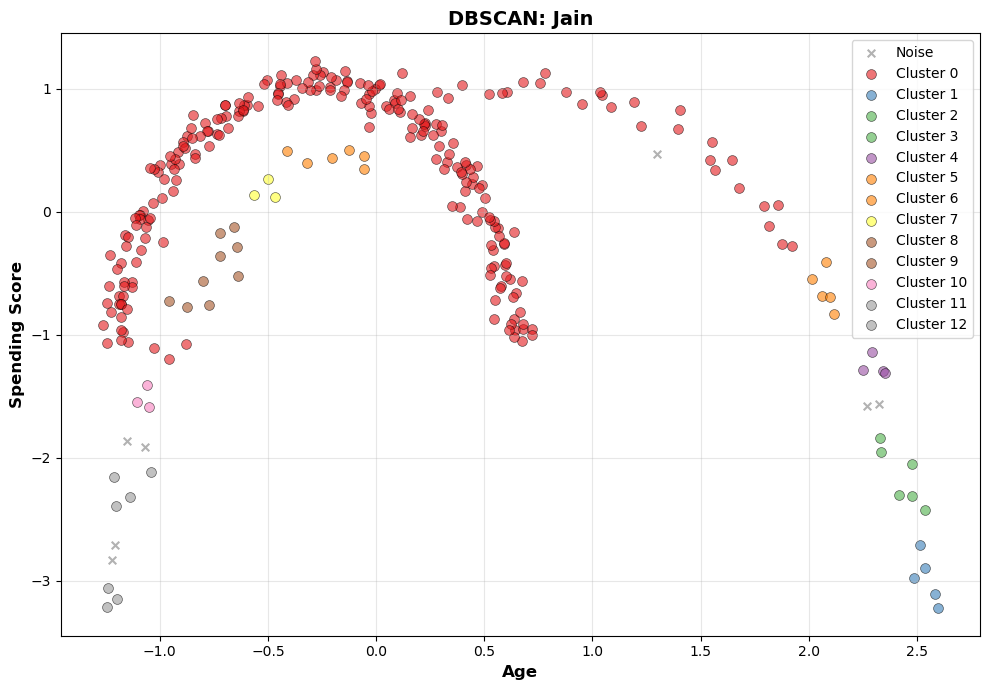

In [43]:
if __name__ == "__main__":
    
    # List of all datasets to test
    dataset_types = [
        'circles', 'moons', 'anisotropic', 'varied_density', 'blobs', 'random',
        'spirals', 'jain', 'flame', 'compound', 'diamonds', 'cross',
        'concentric_rings', 'noisy_moons', 'blobs_with_noise'
    ]

    # just for testing spirals, jain, flame
    sjf_test = ['spirals', 'jain']

    print("\n" + "=" * 80)
    print("CLUSTERING COMPARISON: Hierarchical vs Partitional Methods")
    print(f"Testing {len(dataset_types)} different dataset types")
    print("=" * 80)
    
    # Option 1: View all original datasets first
    print("\n📊 Showing all original datasets...")
    n_datasets = len(dataset_types)
    n_cols = 5
    n_rows = (n_datasets + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
    axes = axes.flatten()
    
    for i, dataset_type in enumerate(dataset_types):
        gen = DatasetGenerator(dataset_type, n_samples=300)
        gen.generate()
        X, y, k = gen.get_data()
        
        axes[i].scatter(X[:, 0], X[:, 1], c='steelblue', s=30, alpha=0.6,
                       edgecolors='black', linewidth=0.3)
        axes[i].set_title(dataset_type.replace('_', ' ').title(),
                         fontsize=11, fontweight='bold')
        axes[i].set_xticks([])
        axes[i].set_yticks([])
        axes[i].set_aspect('equal', adjustable='box')
        for spine in axes[i].spines.values():
            spine.set_visible(False)
    
    # Hide unused subplots
    for i in range(n_datasets, len(axes)):
        axes[i].axis('off')
    
    plt.suptitle('Gallery of All Available Datasets', fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.show()

    # Apply all types of clustering (KMeans, KMedoids, Agglomerative((single, complete, average, ward)) to all dataset types and plot each in their own figure
    for i, dataset_type in enumerate(dataset_types):
        gen = DatasetGenerator(dataset_type, n_samples=300)
        gen.generate()
        X, y, k = gen.get_data()

        # =========KMeans============ 
        #labels = apply_kmeans(X, n_clusters=k)
        #plot_clusters(X, labels, f'K-Means: {dataset_type.replace("_", " ").title()}')
        #
        ## ===========K-Medoids=========
        #labels = apply_kmedoids(X, n_clusters=k)
        #plot_clusters(X, labels, f'K-Medoids: {dataset_type.replace("_", " ").title()}')
        #
        #
        ## =========Agglomerative======
        #
        #labels = apply_agglomerative(X, n_clusters=k, linkage_type='single')
        #plot_clusters(X, labels, f'Agglomerative Clustering (Single): {dataset_type.replace("_", " ").title()}')
        #
        #labels = apply_agglomerative(X, n_clusters=k, linkage_type='complete')
        #plot_clusters(X, labels, f'Agglomerative Clustering (Complete): {dataset_type.replace("_", " ").title()}')
        #
        #labels = apply_agglomerative(X, n_clusters=k, linkage_type='average')
        #plot_clusters(X, labels, f'Agglomerative Clustering (Average): {dataset_type.replace("_", " ").title()}')
        #
        #labels = apply_agglomerative(X, n_clusters=k, linkage_type='ward')
        #plot_clusters(X, labels, f'Agglomerative Clustering (Ward): {dataset_type.replace("_", " ").title()}')

        # ===========DBSCAN===========

        #labels = apply_dbscan(X, eps=0.3, min_samples=8)
        #plot_clusters(X, labels, f'DBSCAN: {dataset_type.replace("_", " ").title()}')

    # just testing spirals, jain, and flame
    for i, dataset_type in enumerate(sjf_test):
        gen = DatasetGenerator(dataset_type, n_samples=300)
        gen.generate()
        X, y, k = gen.get_data()

        labels = apply_dbscan(X, eps=0.20, min_samples=3)
        plot_clusters(X, labels, f'DBSCAN: {dataset_type.replace("_", " ").title()}')

        
    
    
        


# 8x16 table to show yes or no results for clustering method and results on dataset
| dataset | k-means++ | k-medoids | agglomerative (single) | agglomerative (complete) | agglomerative (average) | agglomerative (ward) | DBSCAN |
| --- | --- | --- | --- | --- | --- | --- | --- |
| circles | NO| NO | YES | NO | NO | NO | YES |
| moons | NO | NO | YES | NO | NO | NO | YES |
| anisotropic | YES | YES | YES | NO | YES | YES | YES |
| varied_density | NO | NO | NO | NO | NO | YES | YES |
| blobs | YES | YES | YES | YES | YES | YES | YES |
| random | NO | NO | NO | NO | NO | NO | NO |
| spirals | NO | NO | NO | NO | NO | NO |  |
| jain | NO | NO | NO | NO | NO | NO |  |
| flame | NO | NO | NO | NO | NO | NO | YES |
| compound | YES | YES | YES | YES | YES | YES | YES |
| diamonds | YES | NO | YES | NO | NO | NO | YES |
| cross | YES | NO | NO | NO | NO | NO | NO |
| concentric_rings | NO | NO | YES | NO | NO | NO | YES |
| noisy_moons | NO | NO | NO | NO | NO | NO | YES |
| blobs_with_noise | NO | NO | NO | NO | NO | NO | YES |